### Kaggle Predicting the Beats-per-Minute of Songs

| 변수명                      | 설명                          | 타입/범위          | 해석 포인트 |
|-----------------------------|-------------------------------|--------------------|-------------|
| id                          | 샘플 고유 번호                 | 정수형             | 학습에는 불필요 (식별자) |
| RhythmScore                 | 리듬의 규칙성·안정성 점수       | 실수형 (0~1)       | 높을수록 일정하고 뚜렷한 리듬 |
| AudioLoudness               | 평균 음량 크기 (dB 단위 추정)  | 실수형 (음수, -20~0)| 0에 가까울수록 더 큰 음량 |
| VocalContent                | 보컬 비중                     | 실수형 (0~1)       | 0=보컬 없음, 1=보컬 강함 |
| AcousticQuality             | 어쿠스틱 특성 점수             | 실수형 (0~1)       | 어쿠스틱 성향이 강할수록 높음 |
| InstrumentalScore           | 기악(악기) 기반 점수           | 실수형 (0~1)       | 순수 연주곡에 가까울수록 높음 |
| LivePerformanceLikelihood   | 라이브 공연일 가능성           | 실수형 (0~1)       | 라이브 느낌이 강하면 값이 큼 |
| MoodScore                   | 분위기·감성 점수              | 실수형 (0~1)       | 밝음/어두움 등 감정적 특성 |
| TrackDurationMs             | 곡 길이 (밀리초 단위)          | 실수형 (약 60k~300k)| 60,000=1분, 300,000=5분 |
| Energy                      | 곡의 에너지 강도              | 실수형 (0~1)       | 빠르고 강렬할수록 높음 |
| ⭐️ BeatsPerMinute              | BPM (분당 박자 수, 타깃 변수)  | 실수형 (60~200+)   | 빠른 템포=댄스곡, 느린 템포=발라드 |

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

In [125]:
train = pd.read_csv('./train.csv')
test = pd.read_csv('./test.csv')

train.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [126]:
print(train.shape, test.shape)
train.info() # 9개의 독립변수와 1개의 종속 변수

(524164, 11) (174722, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524164 entries, 0 to 524163
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         524164 non-null  int64  
 1   RhythmScore                524164 non-null  float64
 2   AudioLoudness              524164 non-null  float64
 3   VocalContent               524164 non-null  float64
 4   AcousticQuality            524164 non-null  float64
 5   InstrumentalScore          524164 non-null  float64
 6   LivePerformanceLikelihood  524164 non-null  float64
 7   MoodScore                  524164 non-null  float64
 8   TrackDurationMs            524164 non-null  float64
 9   Energy                     524164 non-null  float64
 10  BeatsPerMinute             524164 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 44.0 MB


In [127]:
train.describe()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,262081.500000,0.632843,-8.379014,0.074443,0.262913,0.117690,0.178398,0.555843,241903.692949,0.500923,119.034899
std,151313.257587,0.156899,4.616221,0.049939,0.223120,0.131845,0.118186,0.225480,59326.601501,0.289952,26.468077
min,0.000000,0.076900,-27.509725,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067,46.718000
25%,131040.750000,0.515850,-11.551933,0.023500,0.069413,0.000001,0.077637,0.403921,207099.876625,0.254933,101.070410
50%,262081.500000,0.634686,-8.252499,0.066425,0.242502,0.074247,0.166327,0.564817,243684.058150,0.511800,118.747660
75%,393122.250000,0.739179,-4.912298,0.107343,0.396957,0.204065,0.268946,0.716633,281851.658500,0.746000,136.686590
max,524163.000000,0.975000,-1.357000,0.256401,0.995000,0.869258,0.599924,0.978000,464723.228100,1.000000,206.037000


In [128]:
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    # ID 컬럼 제거
    df_copy.drop('id', axis=1, inplace=True)
    return df_copy

In [129]:
train_df = get_preprocessed_df(train)

#### Data Visualization

In [130]:
# int64, float64(연속형) dtype들만 컬럼들 선택
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns 
print(numerical_cols)

# 팔레트 색상 선택 연속형 컬럼들 숫자에 맞춰서
palette = sns.color_palette("husl", len(numerical_cols))
print(len(palette))

Index(['RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality',
       'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore',
       'TrackDurationMs', 'Energy', 'BeatsPerMinute'],
      dtype='object')
10


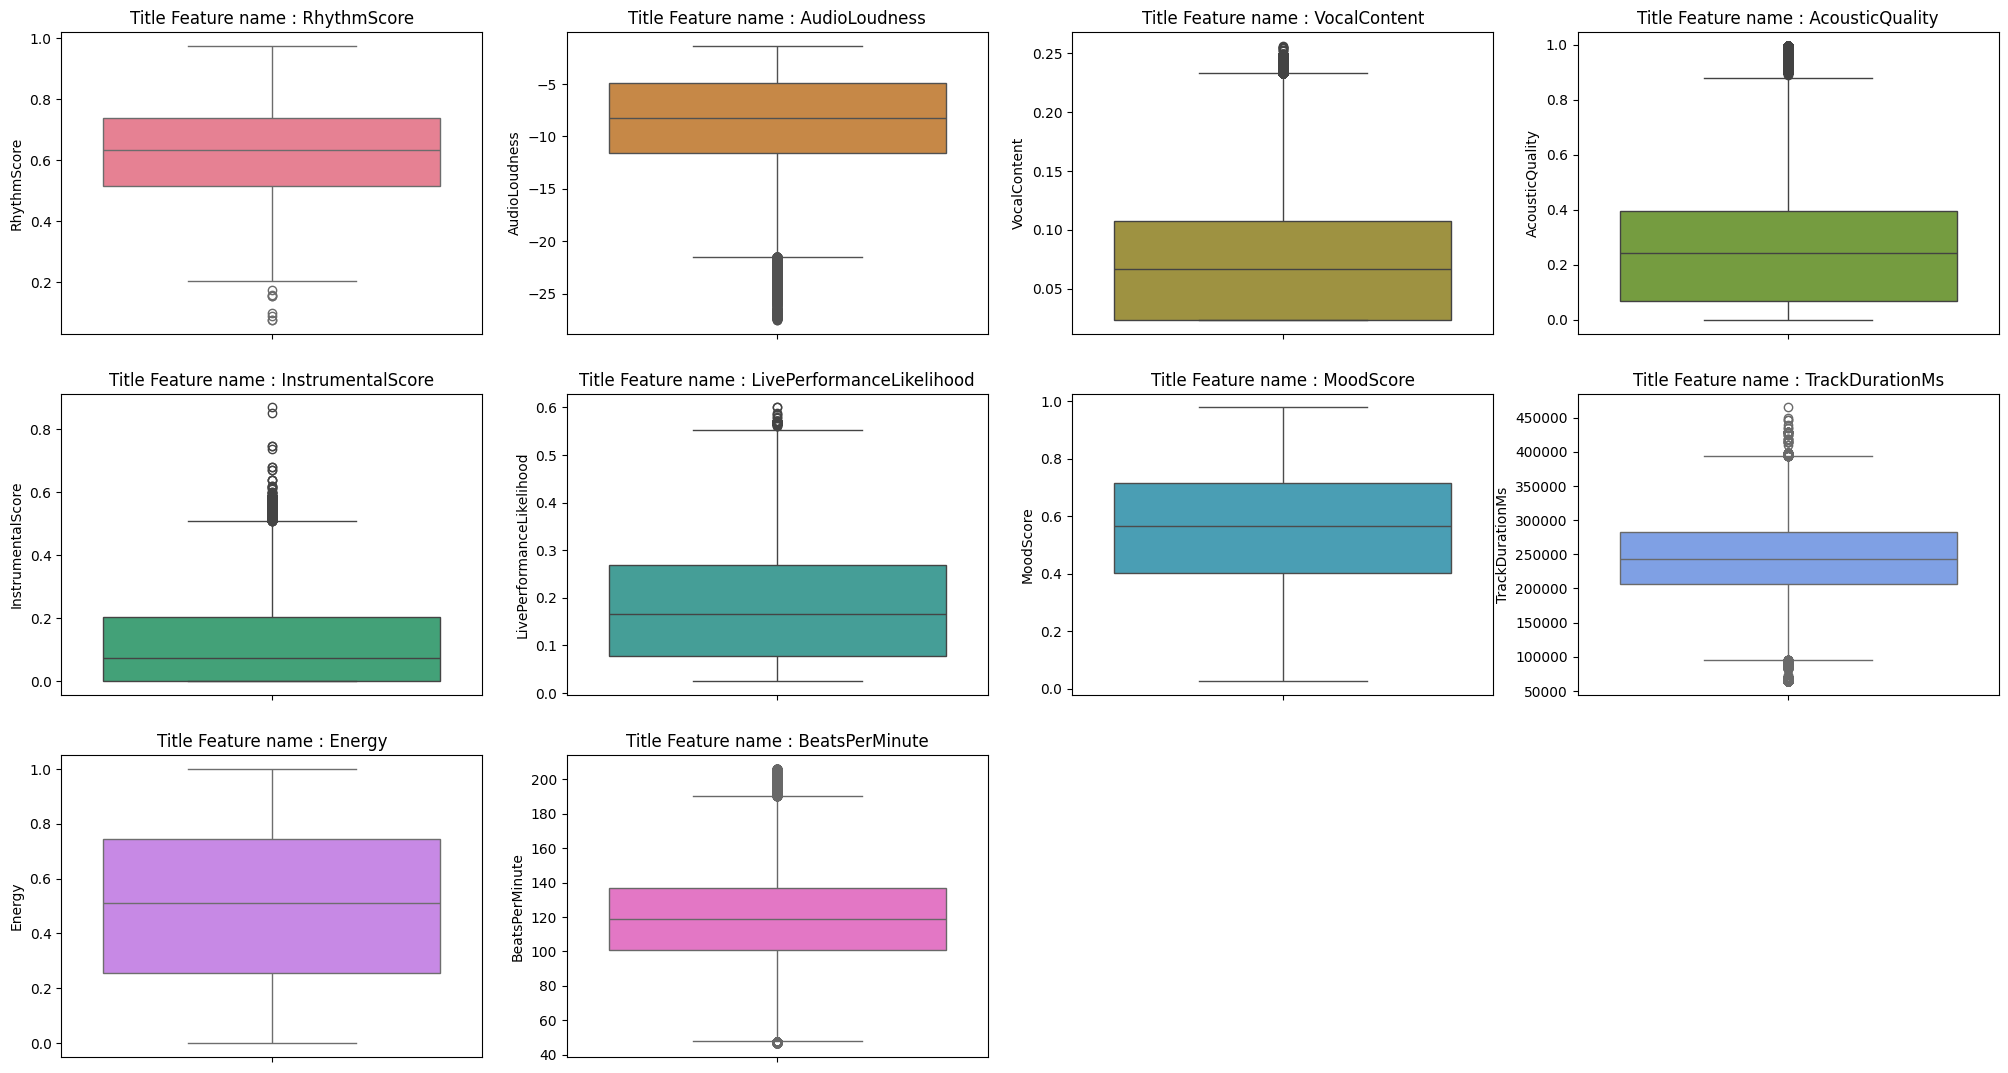

In [131]:
# boxplot 시각화
plt.figure(figsize=(25, 18))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(data=train_df[col], color=palette[i-1])
    plt.title('Title Feature name : {0}'.format(col))

1 RhythmScore
2 AudioLoudness
3 VocalContent
4 AcousticQuality
5 InstrumentalScore
6 LivePerformanceLikelihood
7 MoodScore
8 TrackDurationMs
9 Energy
10 BeatsPerMinute


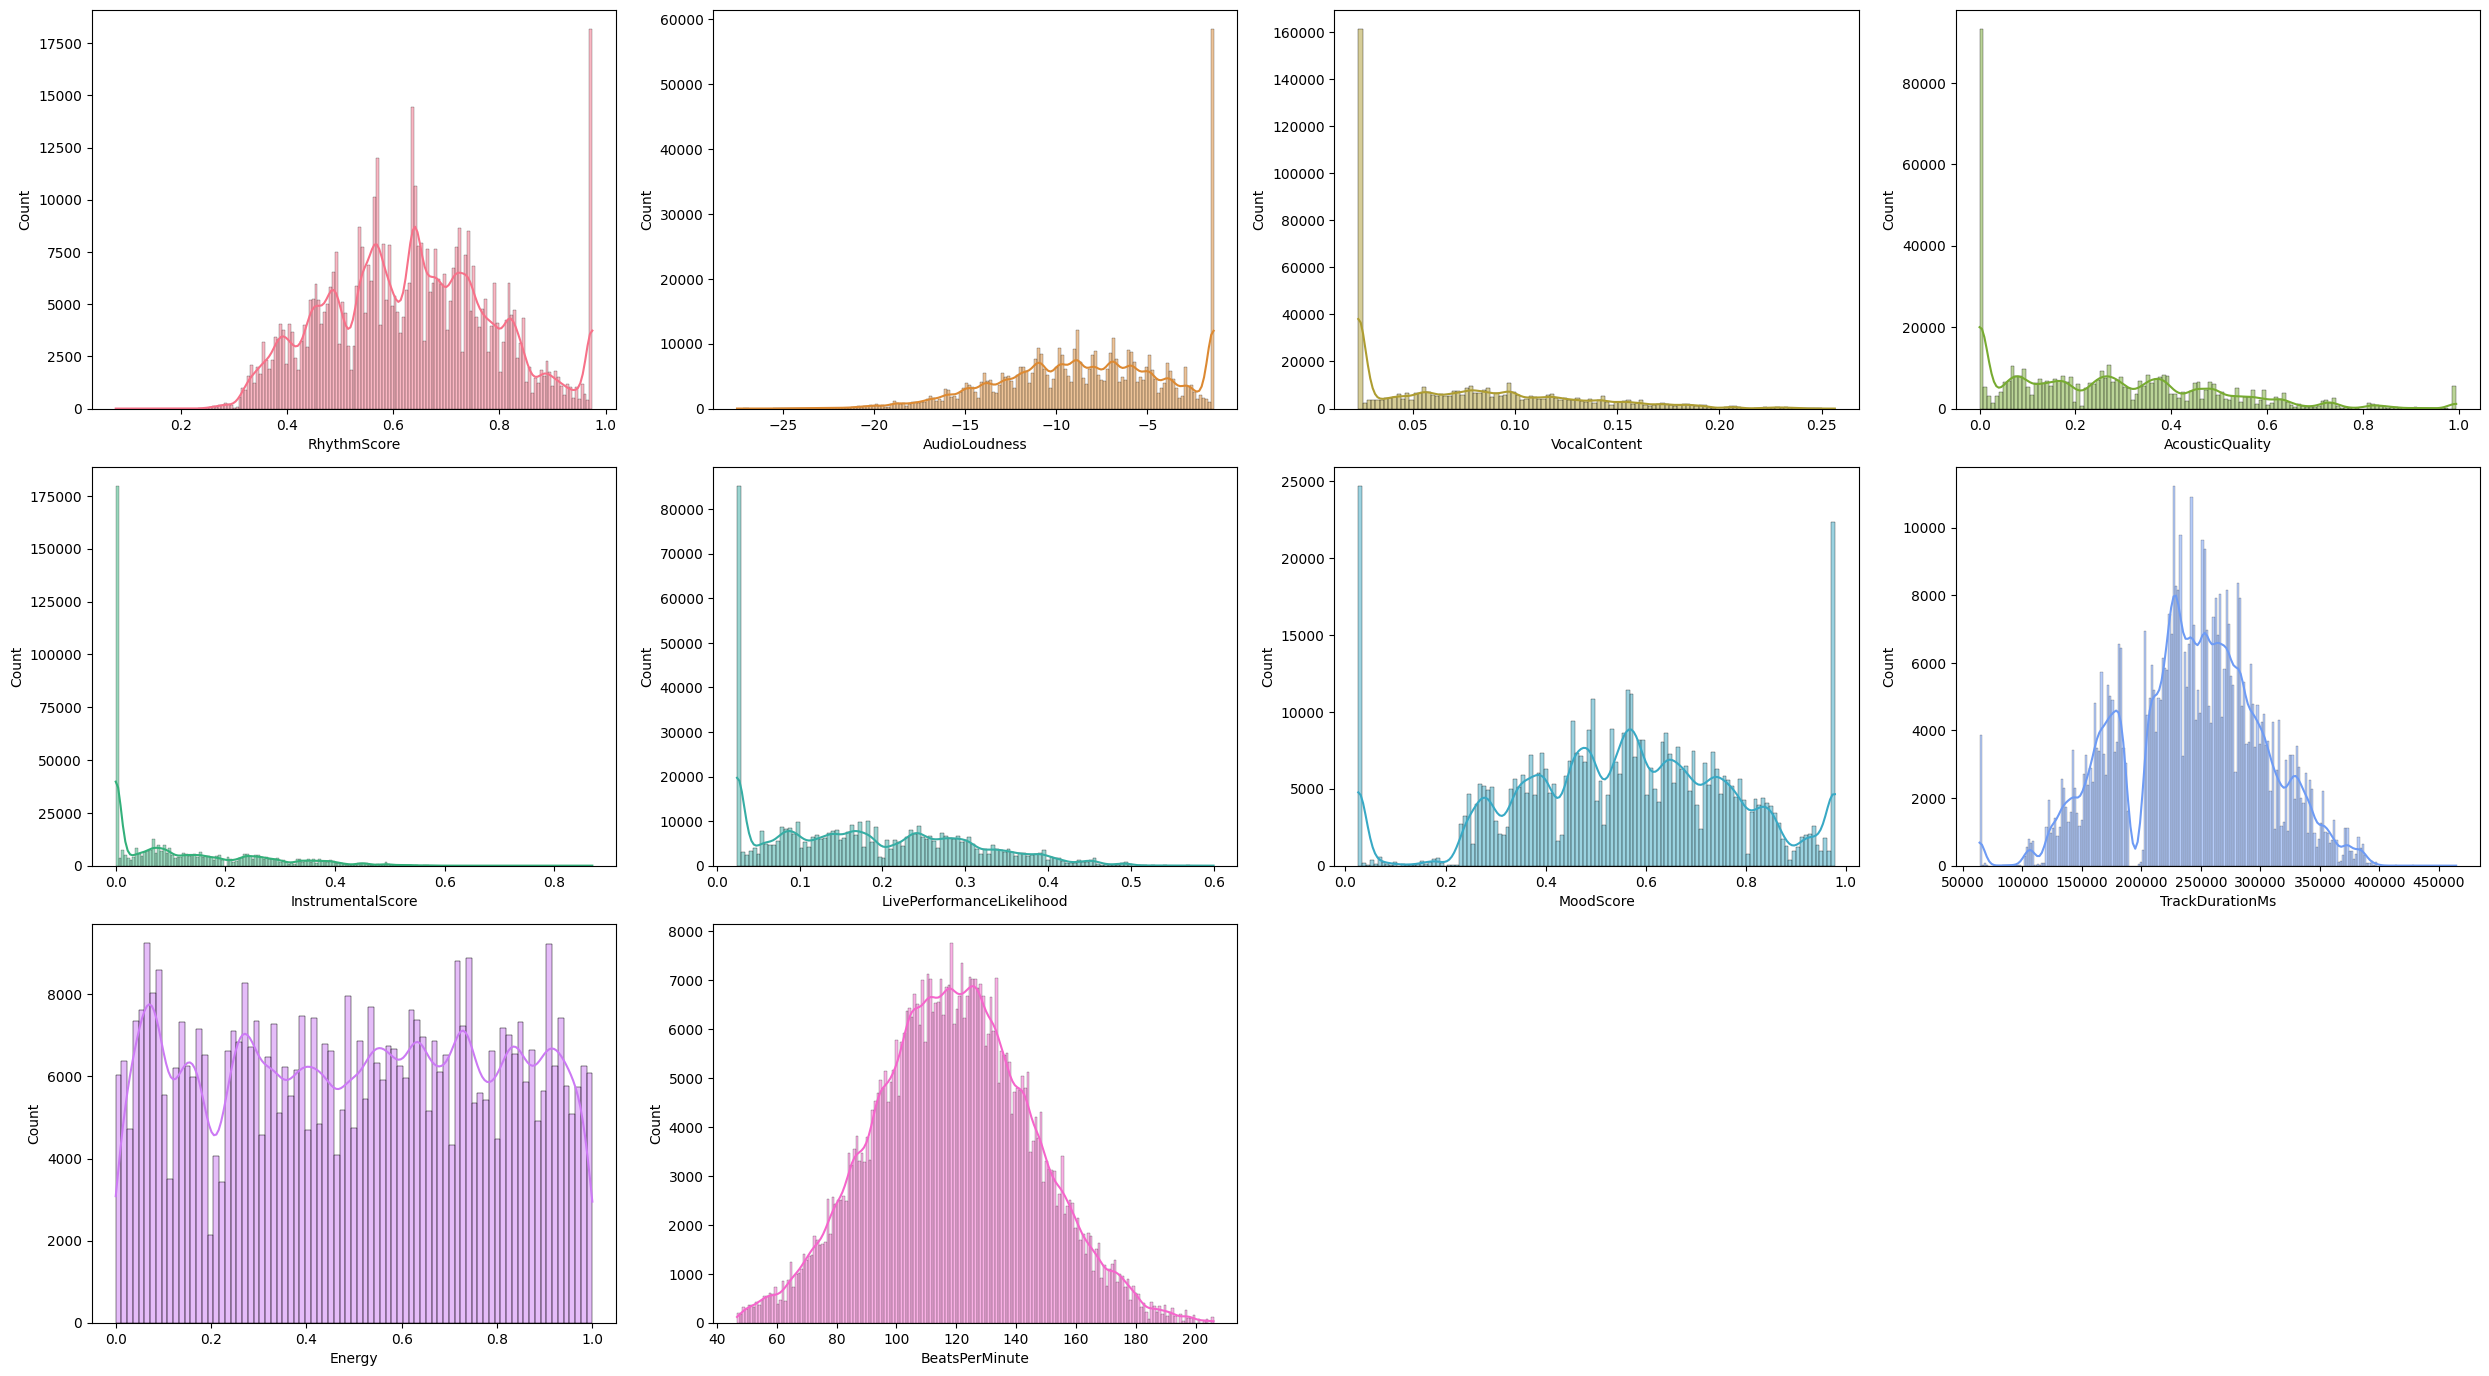

In [132]:
# 히스토그램 시각화
plt.figure(figsize=(25, 18))
for i, col in enumerate(numerical_cols, 1):
    print(i, col)
    plt.subplot(4, 4, i)
    sns.histplot(data=train_df[col], kde=True, color=palette[i-1])
plt.tight_layout()
plt.show()


In [133]:
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    # ID 컬럼 제거
    df_copy.drop('id', axis=1, inplace=True)

    # 4개의 독립 변수에 대해 log 변환
    cols_to_log = ["VocalContent", "AcousticQuality", 
               "InstrumentalScore", "LivePerformanceLikelihood"]
    
    for col in cols_to_log:
        df_copy[col] = np.log1p(df_copy[col])

    return df_copy

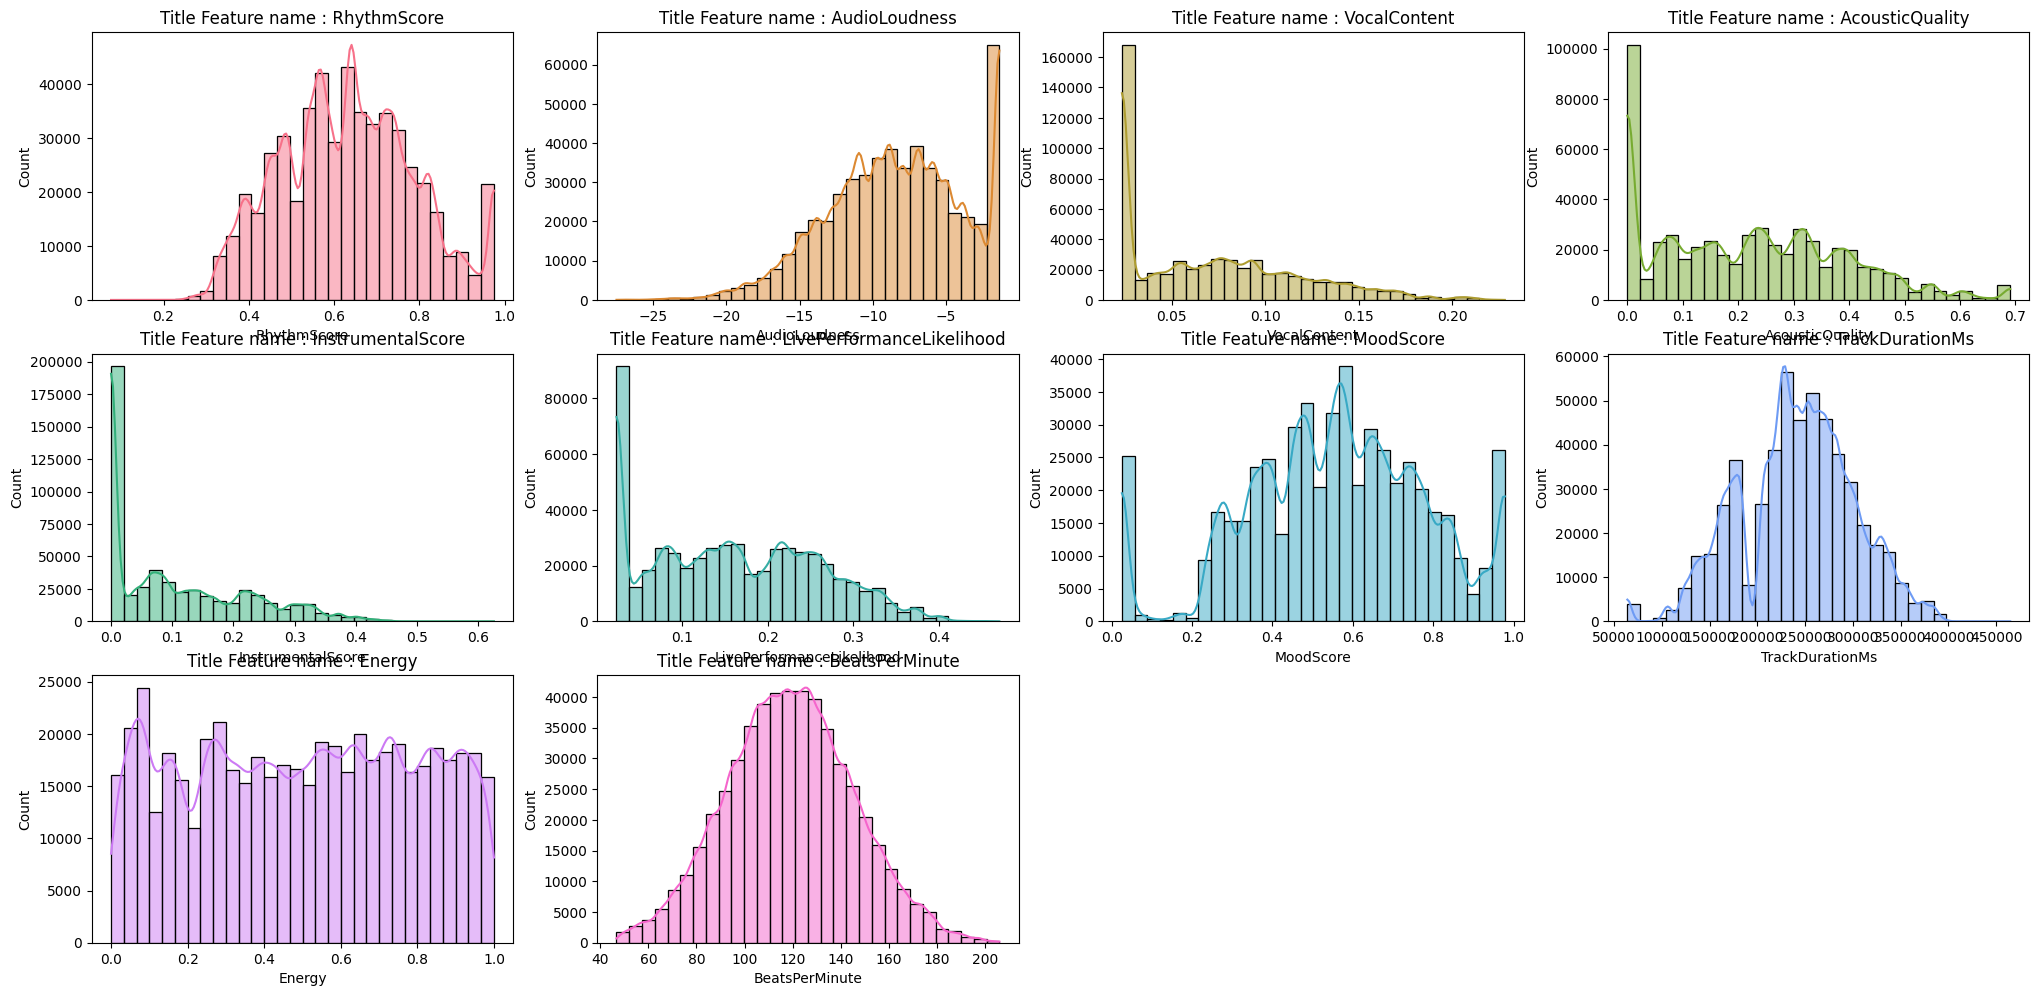

In [134]:
train_df = get_preprocessed_df(train)

plt.figure(figsize=(25, 16))
for i, col in enumerate(numerical_cols, 1): # 인덱스를 1부터 시작하도록 enumberate를 선언
    plt.subplot(4, 4, i) # 4행 4열의 시각화를 하기 위해 subplot 선언
    sns.histplot(data=train_df[col], color=palette[i-1], bins=30, kde=True)
    plt.title(f"Title Feature name : {col}")
    



In [135]:
train_df.head()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0.603610,-7.636942,0.023228,0.000005,0.000001,0.050109,0.409866,290715.6450,0.826267,147.53020
1,0.639451,-16.267598,0.069078,0.368060,0.299671,0.157450,0.651010,164519.5174,0.145400,136.15963
2,0.514538,-15.953575,0.105004,0.160160,0.374191,0.029147,0.423865,174495.5667,0.624667,55.31989
3,0.734463,-1.357000,0.051610,0.001649,0.148176,0.082838,0.278745,225567.4651,0.487467,147.91212
4,0.532968,-13.056437,0.023228,0.066431,0.000001,0.286190,0.477769,213960.6789,0.947333,89.58511


In [136]:
# 파생 변수 생성
def add_feature(df=pd.DataFrame) -> pd.DataFrame: # 타입 힌트 input : pd.DataFrame, ouput : pd.DateFrame
    df_copy = df.copy()
    
    # 1. 시간 관련 파생 변수
    # 밀리초 단위보다 분 단위로 변경
    df_copy['TrackDurationMin'] = df_copy['TrackDurationMs'] / 60000 
    # # 한 곡 전체에서 반복되는 총 박자 수
    # df_copy['BeatsTotal'] = (df_copy['BeatsPerMinute'] * df_copy['TrackDurationMs']) / 60000
    # # 단위 시간 대비 박자의 밀집도
    # df_copy['BeatDensity'] = df_copy['BeatsPerMinute'] / df_copy['TrackDurationMs']
    
    # 2. 에너지/음량 관련
    # 곡 길이 대비 음량 크기
    df_copy['NormalizedLoudness'] = df_copy['AudioLoudness'] / df_copy['TrackDurationMin']
    # 시간 대비 에너지 레벨
    df_copy['EnergyPerMinute'] = df_copy['Energy'] / df_copy['TrackDurationMin']
    
    # 3. 보컬 악기 비율
    # 보컬 vs 악기 비중 비교 -> 1e-6 = 0.000001 분모가 0이 되는 것을 방지하여 더해줍니다.
    df_copy['VocalInstrumentalRatio'] = df_copy['VocalContent'] / (df_copy['InstrumentalScore'] + 1e-6)
    # 어쿠스틱 성향 대비 에너지 -> 1e-6 = 0.000001 분모가 0이 되는 것을 방지하여 더해줍니다.
    df_copy['AcousticVsEnergy'] = df_copy['AcousticQuality'] / (df_copy['Energy'] + 1e-6)
    
    # 4. 분위기 상호 작용
    # 감성 점수와 에너지의 상호작용 -> 밝고 에너지가 높을 경우 댄스곡일 확률이 높아집니다.
    df_copy['MoodEnergyInteraction'] = df_copy['MoodScore'] * df_copy['Energy']
    # 라이브 공연에서 느껴지는 분위기 강도
    df_copy['LiveMood'] = df_copy['LivePerformanceLikelihood'] * df_copy['MoodScore']
    
    return df_copy
    

In [137]:
train_df = add_feature(train_df)
print(train_df.shape)
train_df.head()

(524164, 17)


,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute,TrackDurationMin,NormalizedLoudness,EnergyPerMinute,VocalInstrumentalRatio,AcousticVsEnergy,MoodEnergyInteraction,LiveMood
0,0.603610,-7.636942,0.023228,0.000005,0.000001,0.050109,0.409866,290715.6450,0.826267,147.53020,4.845261,-1.576167,0.170531,11221.320069,0.000006,0.338659,0.020538
1,0.639451,-16.267598,0.069078,0.368060,0.299671,0.157450,0.651010,164519.5174,0.145400,136.15963,2.741992,-5.932767,0.053027,0.230511,2.531346,0.094657,0.102502
2,0.514538,-15.953575,0.105004,0.160160,0.374191,0.029147,0.423865,174495.5667,0.624667,55.31989,2.908259,-5.485609,0.214791,0.280614,0.256392,0.264774,0.012354
3,0.734463,-1.357000,0.051610,0.001649,0.148176,0.082838,0.278745,225567.4651,0.487467,147.91212,3.759458,-0.360956,0.129664,0.348297,0.003384,0.135879,0.023091
4,0.532968,-13.056437,0.023228,0.066431,0.000001,0.286190,0.477769,213960.6789,0.947333,89.58511,3.566011,-3.661356,0.265656,11221.320069,0.070124,0.452607,0.136733


#### 모델 생성 및 학습, 검증 세트 분리

In [138]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK

In [139]:
X = train_df.drop('BeatsPerMinute', axis=1)
y = train_df['BeatsPerMinute']

# 전체 데이터 중 80% 학습용 데이터, 20% 테스트 데이터용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 학습 데이터를 다시 학습과 검증 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

    "max_depth": [6, 8, 10],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_lambda": [0.0, 1.0, 3.0],
    "n_estimators": [800, 1200, 1600],
    "tree_method": ["hist"],  # CPU 빠른 학습

In [140]:
xgb_search_space = {
    'max_depth' : hp.quniform('max_depth', 5, 20, 1),
    'min_child_weight' : hp.quniform('min_child_weight', 1, 5 , 1),
    'subsample' : hp.uniform('subsample', 0.7, 1.0),
    'learning_rate' : hp.uniform('learning_rate', 0.01, 0.2),
    'colsample_bytree' : hp.uniform('colsample_bytree', 0.5, 1)
}

def objective_func(search_space: dict) -> dict:
    params = {
        "max_depth": int(search_space["max_depth"]),
        "min_child_weight": int(search_space["min_child_weight"]),
        "subsample": float(search_space["subsample"]),
        "learning_rate": float(search_space["learning_rate"]),
        "colsample_bytree": float(search_space["colsample_bytree"]),
        "objective": "reg:squarederror",     # ✅ 회귀 명시
        "random_state": 42,
    }
    xgb_clf = XGBRegressor(**params, tree_method='hist', eval_metric='rmse')
    
    scores = cross_val_score(xgb_clf, X_train, y_train, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1, error_score='raise')
    rmse = - scores.mean()
    return {"loss" : rmse, "status" : STATUS_OK}

# 실행
trials = Trials()
best = fmin(fn=objective_func, space=xgb_search_space, algo=tpe.suggest, max_evals=50, trials=trials, rstate=np.random.default_rng(seed=9))
print("Best Params:", best)

100%|██████████| 50/50 [04:51<00:00,  5.83s/trial, best loss: 26.466782595433067]
Best Params: {'colsample_bytree': np.float64(0.9952537229859991), 'learning_rate': np.float64(0.01358066493703906), 'max_depth': np.float64(5.0), 'min_child_weight': np.float64(3.0), 'subsample': np.float64(0.8370119072211581)}


In [141]:
print('colsample_bytree : {0}, learning_rate : {1} , max_depth : {2} , min_child_weight : {3} , subsample : {4} '
      .format(best['colsample_bytree'], best['learning_rate'], best['max_depth'], best['min_child_weight'], best['subsample']))

colsample_bytree : 0.9952537229859991, learning_rate : 0.01358066493703906 , max_depth : 5.0 , min_child_weight : 3.0 , subsample : 0.8370119072211581 


In [ ]:
evals = [(X_val, y_val)]
xgb_wrapper = XGBRegressor(
    n_estimators = 400,
    learning_rate = round(best['learning_rate'], 5),
    colsample_bytree=round(best['colsample_bytree'], 5),
    max_depth=int(best['max_depth']),
    min_child_weight=int(best['min_child_weight']),
    subsample=round(best['subsample'], 5),
    early_stopping=200,
    eval_metric='rmse'
)
xgb_wrapper.fit(X_tr, y_tr, eval_set=evals, verbose=True)

pred = xgb_wrapper.predict(X_test)

print(root_mean_squared_error(y_test, pred))

[0]	validation_0-rmse:26.47095
[1]	validation_0-rmse:26.47075
[2]	validation_0-rmse:26.47056
[3]	validation_0-rmse:26.47035
[4]	validation_0-rmse:26.47017
[5]	validation_0-rmse:26.47002
[6]	validation_0-rmse:26.46984
[7]	validation_0-rmse:26.46967
[8]	validation_0-rmse:26.46955
[9]	validation_0-rmse:26.46938
[10]	validation_0-rmse:26.46925
[11]	validation_0-rmse:26.46914
[12]	validation_0-rmse:26.46902
[13]	validation_0-rmse:26.46892
[14]	validation_0-rmse:26.46883
[15]	validation_0-rmse:26.46865
[16]	validation_0-rmse:26.46862
[17]	validation_0-rmse:26.46851
[18]	validation_0-rmse:26.46839
[19]	validation_0-rmse:26.46826
[20]	validation_0-rmse:26.46825
[21]	validation_0-rmse:26.46811
[22]	validation_0-rmse:26.46802
[23]	validation_0-rmse:26.46792
[24]	validation_0-rmse:26.46778
[25]	validation_0-rmse:26.46776
[26]	validation_0-rmse:26.46761
[27]	validation_0-rmse:26.46755
[28]	validation_0-rmse:26.46747
[29]	validation_0-rmse:26.46738
[30]	validation_0-rmse:26.46727
[31]	validation_0-

/Users/songbeom/PythonWorkSpace/ML_Project/venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [16:48:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "early_stopping" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[45]	validation_0-rmse:26.46616
[46]	validation_0-rmse:26.46612
[47]	validation_0-rmse:26.46609
[48]	validation_0-rmse:26.46609
[49]	validation_0-rmse:26.46606
[50]	validation_0-rmse:26.46601
[51]	validation_0-rmse:26.46594
[52]	validation_0-rmse:26.46586
[53]	validation_0-rmse:26.46579
[54]	validation_0-rmse:26.46571
[55]	validation_0-rmse:26.46567
[56]	validation_0-rmse:26.46563
[57]	validation_0-rmse:26.46559
[58]	validation_0-rmse:26.46559
[59]	validation_0-rmse:26.46560
[60]	validation_0-rmse:26.46554
[61]	validation_0-rmse:26.46554
[62]	validation_0-rmse:26.46554
[63]	validation_0-rmse:26.46552
[64]	validation_0-rmse:26.46552
[65]	validation_0-rmse:26.46550
[66]	validation_0-rmse:26.46550
[67]	validation_0-rmse:26.46546
[68]	validation_0-rmse:26.46542
[69]	validation_0-rmse:26.46541
[70]	validation_0-rmse:26.46539
[71]	validation_0-rmse:26.46535
[72]	validation_0-rmse:26.46531
[73]	validation_0-rmse:26.46527
[74]	validation_0-rmse:26.46527
[75]	validation_0-rmse:26.46524
[76]	val

In [149]:
test_df = get_preprocessed_df(test)
test_df  = add_feature(test_df)



pred = xgb_wrapper.predict(test_df)
print(pred)
submission = pd.DataFrame({'id' : test['id'],
                           'BeatsPerMinute' : pred})
submission.to_csv('submission.csv', index=False)

[119.4354   118.21091  118.9819   ... 119.728035 118.626945 120.455   ]


In [ ]:
# X = train_df.drop('BeatsPerMinute', axis=1)
# y = train_df['BeatsPerMinute']

# X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# param_grid = {
#     "learning_rate": [0.02, 0.03, 0.05],
#     "max_depth": [6, 8, 10],
#     "min_child_weight": [1, 5, 10],
#     "subsample": [0.7, 0.85, 1.0],
#     "colsample_bytree": [0.7, 0.85, 1.0],
#     "reg_lambda": [0.0, 1.0, 3.0],
#     "n_estimators": [800, 1200, 1600],
#     "tree_method": ["hist"],  # CPU 빠른 학습
# }

# xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1)
# grid = GridSearchCV(
#     xgb_base, param_grid,
#     scoring="root_mean_squared_error",
#     cv=KFold(n_splits=5, shuffle=True, random_state=42),
#     n_jobs=-1, verbose=1
# )
# grid.fit(X, y)
# print("[XGB/GRID] Best CV RMSE:", round(-grid.best_score_, 4))
# print("[XGB/GRID] Best Params:", grid.best_params_)

# # early stopping은 홀드아웃에서만
# X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# xgb_es = xgb.XGBRegressor(**grid.best_params_, random_state=42, n_estimators=5000, n_jobs=-1)
# xgb_es.fit(
#     X_tr, y_tr,
#     eval_set=[(X_val, y_val)],
#     eval_metric="rmse",
#     early_stopping_rounds=200,
#     verbose=False
# )
# pred = xgb_es.predict(X_val, iteration_range=(0, xgb_es.best_iteration + 1))
# rmse = root_mean_squared_error(y_val, pred)
# print(f"[XGB/ES] best_iteration: {xgb_es.best_iteration}, hold-out RMSE: {rmse:.4f}")

InvalidParameterError: The 'scoring' parameter of GridSearchCV must be a str among {'precision_samples', 'jaccard_macro', 'v_measure_score', 'recall_micro', 'adjusted_rand_score', 'neg_log_loss', 'precision_weighted', 'matthews_corrcoef', 'rand_score', 'explained_variance', 'roc_auc_ovr_weighted', 'neg_negative_likelihood_ratio', 'roc_auc', 'jaccard_weighted', 'neg_root_mean_squared_log_error', 'balanced_accuracy', 'neg_mean_squared_log_error', 'neg_brier_score', 'mutual_info_score', 'neg_mean_squared_error', 'precision', 'positive_likelihood_ratio', 'normalized_mutual_info_score', 'neg_mean_gamma_deviance', 'recall_macro', 'f1_micro', 'd2_absolute_error_score', 'f1', 'f1_macro', 'homogeneity_score', 'recall', 'adjusted_mutual_info_score', 'roc_auc_ovo', 'neg_median_absolute_error', 'f1_samples', 'precision_micro', 'neg_mean_poisson_deviance', 'fowlkes_mallows_score', 'top_k_accuracy', 'accuracy', 'jaccard', 'precision_macro', 'roc_auc_ovr', 'recall_samples', 'roc_auc_ovo_weighted', 'r